# Домашнее задание

## 1. Зависимости

Основной стек: PyTorch, sklearn, pandas, matplotlib/seaborn. Для загрузки GloVe используется `kagglehub`, если локальный файл с embeddings не найден.

In [1]:
import importlib.util
import subprocess
import sys

PACKAGE_PLAN = {
    "kagglehub": "kagglehub",
}

missing_packages = [
    install_name
    for module_name, install_name in PACKAGE_PLAN.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Доставляю недостающие пакеты:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *missing_packages])
else:
    print("Все дополнительные пакеты уже установлены.")

Все дополнительные пакеты уже установлены.


## 2. Импорты и конфигурация

In [2]:
from collections import Counter
from pathlib import Path
import math
import os
import random
import re
import time
import urllib.request

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
DATA_DIR = Path("data")
CHECKPOINT_DIR = Path("checkpoints/ag_news_seminar_hybrid")
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_model.pt"

TARGET_MACRO_F1 = 0.95
MAX_EPOCHS = 14
EARLY_STOP_PATIENCE = 4

MAX_VOCAB_SIZE = 60_000
MIN_TOKEN_FREQ = 2
MAX_SEQUENCE_LEN = 120
EMBEDDING_DIM = 300

BATCH_SIZE = 128
EVAL_BATCH_SIZE = 256
NUM_WORKERS = 0

LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP = 1.0

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
ID_TO_LABEL = {idx: name for idx, name in enumerate(LABEL_NAMES)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
PIN_MEMORY = device.type == "cuda"

print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Цель ТЗ: test macro F1 >= {TARGET_MACRO_F1:.2f}")

Устройство: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Цель ТЗ: test macro F1 >= 0.95


## 3. AG News: загрузка и split

train/validation делаем из train-части в пропорции 90/10 с фиксированным seed, test оставляем отдельным.

In [3]:
def fetch_ag_news_csv(data_dir: Path) -> dict[str, Path]:
    data_dir.mkdir(parents=True, exist_ok=True)
    urls = {
        "train": "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv",
        "test": "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv",
    }

    paths = {}
    for split_name, url in urls.items():
        csv_path = data_dir / f"{split_name}.csv"
        if not csv_path.exists():
            print(f"Загружаю {split_name}: {csv_path}")
            urllib.request.urlretrieve(url, csv_path)
        paths[split_name] = csv_path
    return paths


def read_ag_news(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path, header=None, names=["raw_label", "title", "description"])
    frame["text"] = (frame["title"].fillna("") + " " + frame["description"].fillna("")).str.strip()
    frame["label"] = frame["raw_label"].astype(int) - 1
    return frame[["text", "label"]]


csv_paths = fetch_ag_news_csv(DATA_DIR)
train_full = read_ag_news(csv_paths["train"])
test_frame = read_ag_news(csv_paths["test"])

train_frame, valid_frame = train_test_split(
    train_full,
    test_size=0.10,
    stratify=train_full["label"],
    random_state=SEED,
)

print(f"Train: {len(train_frame):,}")
print(f"Valid: {len(valid_frame):,}")
print(f"Test:  {len(test_frame):,}")
display(train_frame.sample(5, random_state=SEED).assign(class_name=lambda df: df["label"].map(ID_TO_LABEL)))

Train: 108,000
Valid: 12,000
Test:  7,600


,text,label,class_name
53973,"Eugene Melnyk stepping down as Biovail CEO, wi...",2,Business
59731,Great Lakes to Get Asian Carp Barrier (AP) AP ...,3,Sci/Tech
110557,Snow to Remain as U.S. Treasury Secretary WAS...,2,Business
117146,Counsell Returns to the Diamondbacks (Reuters)...,1,Sports
111904,Ciena's Loss Tempered By Rise in Revenue Ciena...,3,Sci/Tech


## 4. Баланс классов

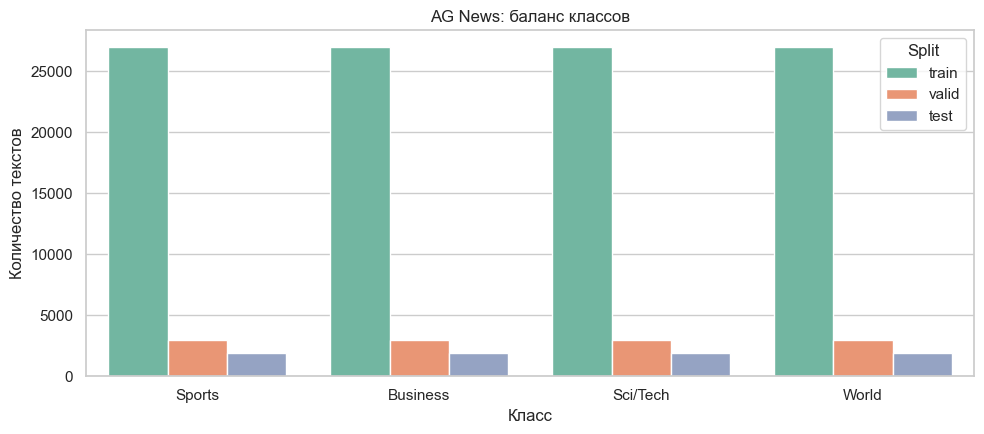

In [4]:
class_balance = pd.concat([
    train_frame.assign(split="train"),
    valid_frame.assign(split="valid"),
    test_frame.assign(split="test"),
])
class_balance["class_name"] = class_balance["label"].map(ID_TO_LABEL)

sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(10, 4.5))
sns.countplot(data=class_balance, x="class_name", hue="split", palette="Set2")
plt.title("AG News: баланс классов")
plt.xlabel("Класс")
plt.ylabel("Количество текстов")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

## 5. Токенизация и словарь

 простая English-токенизация, частотный словарь, индексы слов и динамический padding внутри batch.

In [5]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1


def seminar_tokenize(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"\\", " ", text)
    text = re.sub(r"\b(19|20)\d{2}\b", " <year> ", text)
    text = re.sub(r"([.,!?;:()\[\]{}\"'])", r" \1 ", text)
    text = re.sub(r"n't\b", " n't", text)
    text = re.sub(r"'(s|m|re|ve|ll|d)\b", r" '\1", text)
    text = re.sub(r"[^a-z0-9<>$%.,!?;:()\[\]{}\"'\s/-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return [token for token in text.split() if token]


def build_vocabulary(texts: pd.Series, min_freq: int, max_size: int) -> dict[str, int]:
    counter = Counter()
    for text in tqdm(texts, desc="Собираю словарь", leave=False):
        counter.update(seminar_tokenize(text))

    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for token, freq in counter.most_common(max_size - len(vocab)):
        if freq < min_freq:
            break
        vocab[token] = len(vocab)
    return vocab


vocab = build_vocabulary(train_frame["text"], MIN_TOKEN_FREQ, MAX_VOCAB_SIZE)
print(f"Размер словаря: {len(vocab):,}")
print("Первые токены:", list(vocab.items())[:12])

Собираю словарь:   0%|          | 0/108000 [00:00<?, ?it/s]

Размер словаря: 49,075
Первые токены: [('<pad>', 0), ('<unk>', 1), ('.', 2), ('the', 3), (',', 4), ('to', 5), ('a', 6), ('of', 7), ('in', 8), (';', 9), ('and', 10), ('s', 11)]


## 6. Предобученные embeddings

Используем GloVe 6B 300d Если файл уже скачан, он будет найден локально; иначе notebook попробует скачать его через `kagglehub`.

In [6]:
def resolve_glove_path() -> Path | None:
    candidates = [
        os.environ.get("GLOVE_PATH"),
        DATA_DIR / "glove.6B.300d.txt",
        Path("glove.6B.300d.txt"),
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return Path(candidate)

    try:
        import kagglehub

        glove_dir = Path(kagglehub.dataset_download("thanakomsn/glove6b300dtxt"))
        glove_path = glove_dir / "glove.6B.300d.txt"
        if glove_path.exists():
            return glove_path
    except Exception as error:
        print("GloVe не удалось скачать автоматически:", repr(error))

    return None


def build_embedding_matrix(glove_path: Path | None, vocab: dict[str, int], embed_dim: int) -> torch.Tensor:
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0.0, 0.08, size=(len(vocab), embed_dim)).astype(np.float32)
    matrix[PAD_IDX] = np.zeros(embed_dim, dtype=np.float32)

    if glove_path is None:
        print("Работаем со случайной инициализацией embeddings. Для цели 0.95 лучше подключить GloVe.")
        return torch.tensor(matrix)

    hits = 0
    with open(glove_path, "r", encoding="utf-8") as handle:
        for line in tqdm(handle, desc="Читаю GloVe", total=400_000, leave=False):
            parts = line.rstrip().split(" ")
            token = parts[0]
            if token not in vocab or len(parts) != embed_dim + 1:
                continue
            matrix[vocab[token]] = np.asarray(parts[1:], dtype=np.float32)
            hits += 1

    print(f"GloVe path: {glove_path}")
    print(f"Найдено embeddings: {hits:,}/{len(vocab):,} ({hits / len(vocab):.1%})")
    return torch.tensor(matrix)


glove_path = resolve_glove_path()
embedding_matrix = build_embedding_matrix(glove_path, vocab, EMBEDDING_DIM)
print("Embedding matrix:", tuple(embedding_matrix.shape))

Читаю GloVe:   0%|          | 0/400000 [00:00<?, ?it/s]

GloVe path: C:\Users\ART PRONKIN\.cache\kagglehub\datasets\thanakomsn\glove6b300dtxt\versions\1\glove.6B.300d.txt
Найдено embeddings: 43,398/49,075 (88.4%)
Embedding matrix: (49075, 300)


## 7. Dataset и DataLoader

In [7]:
class AGNewsIndexedDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, vocab: dict[str, int], max_len: int):
        self.texts = frame["text"].to_list()
        self.labels = frame["label"].astype(int).to_list()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        tokens = seminar_tokenize(self.texts[index])[: self.max_len]
        ids = [self.vocab.get(token, UNK_IDX) for token in tokens]
        if not ids:
            ids = [UNK_IDX]
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(len(ids), dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long),
        )


def collate_news_batch(batch):
    sequences, lengths, labels = zip(*batch)
    batch_size = len(sequences)
    max_len = max(int(length) for length in lengths)
    padded = torch.full((batch_size, max_len), PAD_IDX, dtype=torch.long)
    for row, sequence in enumerate(sequences):
        padded[row, : sequence.numel()] = sequence
    return padded, torch.stack(lengths), torch.stack(labels)


def make_loader(dataset: Dataset, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_news_batch,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )


train_dataset = AGNewsIndexedDataset(train_frame, vocab, MAX_SEQUENCE_LEN)
valid_dataset = AGNewsIndexedDataset(valid_frame, vocab, MAX_SEQUENCE_LEN)
test_dataset = AGNewsIndexedDataset(test_frame, vocab, MAX_SEQUENCE_LEN)

train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True)
valid_loader = make_loader(valid_dataset, EVAL_BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_dataset, EVAL_BATCH_SIZE, shuffle=False)

sample_tokens, sample_lengths, sample_labels = next(iter(train_loader))
print("Batch tokens:", tuple(sample_tokens.shape))
print("Batch lengths:", tuple(sample_lengths.shape))
print("Batch labels:", tuple(sample_labels.shape))

Batch tokens: (128, 95)
Batch lengths: (128,)
Batch labels: (128,)


## 8. Модель: BiLSTM + TextCNN внутри одной архитектуры


In [8]:
class SeminarHybridClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix: torch.Tensor,
        num_classes: int,
        pad_idx: int,
        lstm_hidden: int = 256,
        lstm_layers: int = 2,
        cnn_filters: int = 192,
        kernel_sizes: tuple[int, ...] = (2, 3, 4, 5),
        dropout: float = 0.45,
        embedding_dropout: float = 0.20,
    ):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False,
            padding_idx=pad_idx,
        )
        self.embedding_dropout = nn.Dropout1d(embedding_dropout)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.25 if lstm_layers > 1 else 0.0,
        )
        lstm_dim = lstm_hidden * 2

        self.attention = nn.Sequential(
            nn.Linear(lstm_dim, lstm_hidden),
            nn.Tanh(),
            nn.Linear(lstm_hidden, 1),
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, cnn_filters, kernel_size=kernel_size)
            for kernel_size in kernel_sizes
        ])

        feature_dim = lstm_dim * 3 + cnn_filters * len(kernel_sizes)
        self.classifier = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(dropout),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, tokens: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        mask = tokens.ne(self.pad_idx)
        embedded = self.embedding(tokens)
        embedded = self.embedding_dropout(embedded.transpose(1, 2)).transpose(1, 2)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_outputs, _ = self.lstm(packed)
        lstm_outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=tokens.size(1),
        )

        attention_scores = self.attention(lstm_outputs).squeeze(-1)
        attention_scores = attention_scores.masked_fill(~mask, -1e4)
        attention_weights = torch.softmax(attention_scores, dim=1).unsqueeze(-1)
        attention_pool = torch.sum(lstm_outputs * attention_weights, dim=1)

        masked_outputs = lstm_outputs.masked_fill(~mask.unsqueeze(-1), 0.0)
        mean_pool = masked_outputs.sum(dim=1) / lengths.clamp_min(1).unsqueeze(1)
        max_pool = lstm_outputs.masked_fill(~mask.unsqueeze(-1), -1e4).max(dim=1).values

        cnn_input = embedded.transpose(1, 2)
        cnn_features = []
        for conv in self.convs:
            if cnn_input.size(-1) < conv.kernel_size[0]:
                padded = F.pad(cnn_input, (0, conv.kernel_size[0] - cnn_input.size(-1)))
            else:
                padded = cnn_input
            feature = F.relu(conv(padded))
            cnn_features.append(F.max_pool1d(feature, kernel_size=feature.size(2)).squeeze(2))

        features = torch.cat([attention_pool, mean_pool, max_pool, *cnn_features], dim=1)
        return self.classifier(features)


model = SeminarHybridClassifier(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABEL_NAMES),
    pad_idx=PAD_IDX,
).to(device)

trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
print(f"Обучаемых параметров: {trainable_params:,}")

Обучаемых параметров: 19,567,817


## 9. Метрики и цикл обучения

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=MAX_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.12,
    div_factor=10,
    final_div_factor=100,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def to_device(tokens, lengths, labels):
    return (
        tokens.to(device, non_blocking=PIN_MEMORY),
        lengths.to(device, non_blocking=PIN_MEMORY),
        labels.to(device, non_blocking=PIN_MEMORY),
    )


def summarize_predictions(labels: list[int], predictions: list[int], loss_values: list[float]) -> dict[str, float]:
    return {
        "loss": float(np.mean(loss_values)),
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }


def train_epoch(model: nn.Module, loader: DataLoader, epoch: int) -> dict[str, float]:
    model.train()
    loss_values, predictions, labels_gold = [], [], []

    progress = tqdm(loader, desc=f"Эпоха {epoch:02d}: train", leave=False)
    for tokens, lengths, labels in progress:
        tokens, lengths, labels = to_device(tokens, lengths, labels)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(tokens, lengths)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_values.append(loss.item())
        batch_predictions = logits.argmax(dim=1).detach().cpu().numpy()
        predictions.extend(batch_predictions.tolist())
        labels_gold.extend(labels.detach().cpu().numpy().tolist())
        progress.set_postfix(loss=f"{np.mean(loss_values):.4f}")

    return summarize_predictions(labels_gold, predictions, loss_values)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, caption: str) -> dict[str, object]:
    model.eval()
    loss_values, predictions, labels_gold = [], [], []

    for tokens, lengths, labels in tqdm(loader, desc=caption, leave=False):
        tokens, lengths, labels = to_device(tokens, lengths, labels)
        logits = model(tokens, lengths)
        loss = criterion(logits, labels)
        loss_values.append(loss.item())
        batch_predictions = logits.argmax(dim=1).detach().cpu().numpy()
        predictions.extend(batch_predictions.tolist())
        labels_gold.extend(labels.detach().cpu().numpy().tolist())

    metrics = summarize_predictions(labels_gold, predictions, loss_values)
    metrics["labels"] = labels_gold
    metrics["predictions"] = predictions
    return metrics


def save_best_model(model: nn.Module, path: Path, meta: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state": model.state_dict(),
            "vocab": vocab,
            "config": {
                "max_sequence_len": MAX_SEQUENCE_LEN,
                "embedding_dim": EMBEDDING_DIM,
                "label_names": LABEL_NAMES,
            },
            "meta": meta,
        },
        path,
    )

C:\Users\ART PRONKIN\AppData\Local\Temp\ipykernel_20436\1241067551.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## 10. Обучение до целевого F1

Остановка устроена явно: если validation macro F1 достигает `0.95`, сохраняем модель и выходим из цикла. Если рост остановился раньше, срабатывает patience.

In [10]:
history_rows = []
best_valid_f1 = -1.0
epochs_without_growth = 0
target_reached = False

for epoch in range(1, MAX_EPOCHS + 1):
    started_at = time.time()
    train_metrics = train_epoch(model, train_loader, epoch)
    valid_metrics = evaluate(model, valid_loader, caption=f"Эпоха {epoch:02d}: validation")
    elapsed = time.time() - started_at

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "valid_loss": valid_metrics["loss"],
        "valid_accuracy": valid_metrics["accuracy"],
        "valid_macro_f1": valid_metrics["macro_f1"],
        "learning_rate": scheduler.get_last_lr()[0],
        "seconds": elapsed,
    }
    history_rows.append(row)

    print(
        f"Эпоха {epoch:02d} | "
        f"train F1={row['train_macro_f1']:.4f}, loss={row['train_loss']:.4f} | "
        f"valid F1={row['valid_macro_f1']:.4f}, acc={row['valid_accuracy']:.4f}, "
        f"loss={row['valid_loss']:.4f} | {elapsed:.1f}s"
    )

    if row["valid_macro_f1"] > best_valid_f1:
        best_valid_f1 = row["valid_macro_f1"]
        epochs_without_growth = 0
        save_best_model(model, CHECKPOINT_PATH, meta=row)
        print(f"  Сохранил лучший checkpoint: validation macro F1 = {best_valid_f1:.4f}")
    else:
        epochs_without_growth += 1
        print(f"  Без улучшения: {epochs_without_growth}/{EARLY_STOP_PATIENCE}")

    if row["valid_macro_f1"] >= TARGET_MACRO_F1:
        target_reached = True
        print(f"Цель на validation достигнута: {row['valid_macro_f1']:.4f} >= {TARGET_MACRO_F1:.2f}")
        break

    if epochs_without_growth >= EARLY_STOP_PATIENCE:
        print("Ранняя остановка: validation F1 больше не растет.")
        break

history = pd.DataFrame(history_rows)
print(f"Лучший validation macro F1: {best_valid_f1:.4f}")
display(history)

Эпоха 01: train:   0%|          | 0/844 [00:00<?, ?it/s]

C:\Users\ART PRONKIN\AppData\Local\Temp\ipykernel_20436\1241067551.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Эпоха 01: validation:   0%|          | 0/47 [00:00<?, ?it/s]

Эпоха 01 | train F1=0.8806, loss=0.4904 | valid F1=0.9177, acc=0.9178, loss=0.4059 | 148.5s
  Сохранил лучший checkpoint: validation macro F1 = 0.9177


Эпоха 02: train:   0%|          | 0/844 [00:00<?, ?it/s]

...

Эпоха 07: train:   0%|          | 0/844 [00:00<?, ?it/s]

C:\Users\ART PRONKIN\AppData\Local\Temp\ipykernel_20436\1241067551.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Эпоха 07: validation:   0%|          | 0/47 [00:00<?, ?it/s]

Эпоха 07 | train F1=0.9893, loss=0.2337 | valid F1=0.9232, acc=0.9233, loss=0.4247 | 127.6s
  Без улучшения: 4/4
Ранняя остановка: validation F1 больше не растет.
Лучший validation macro F1: 0.9316


,epoch,train_loss,train_accuracy,train_macro_f1,valid_loss,valid_accuracy,valid_macro_f1,learning_rate,seconds
0,1,0.490359,0.880787,0.880564,0.405902,0.917833,0.917713,0.001366,148.531291
1,2,0.404129,0.922935,0.922838,0.386979,0.927417,0.927079,0.001997,148.802876
2,3,0.337765,0.948241,0.948223,0.365160,0.931667,0.931582,0.001944,148.231465
3,4,0.290543,0.967056,0.967056,0.381891,0.931417,0.931379,0.001830,122.962032
4,5,0.263407,0.978000,0.978003,0.392069,0.929417,0.929439,0.001663,119.907382
5,6,0.246362,0.984130,0.984132,0.404971,0.928250,0.928205,0.001452,130.815481
6,7,0.233748,0.989250,0.989251,0.424688,0.923250,0.923211,0.001213,127.638898


## 11. Визуализация обучения

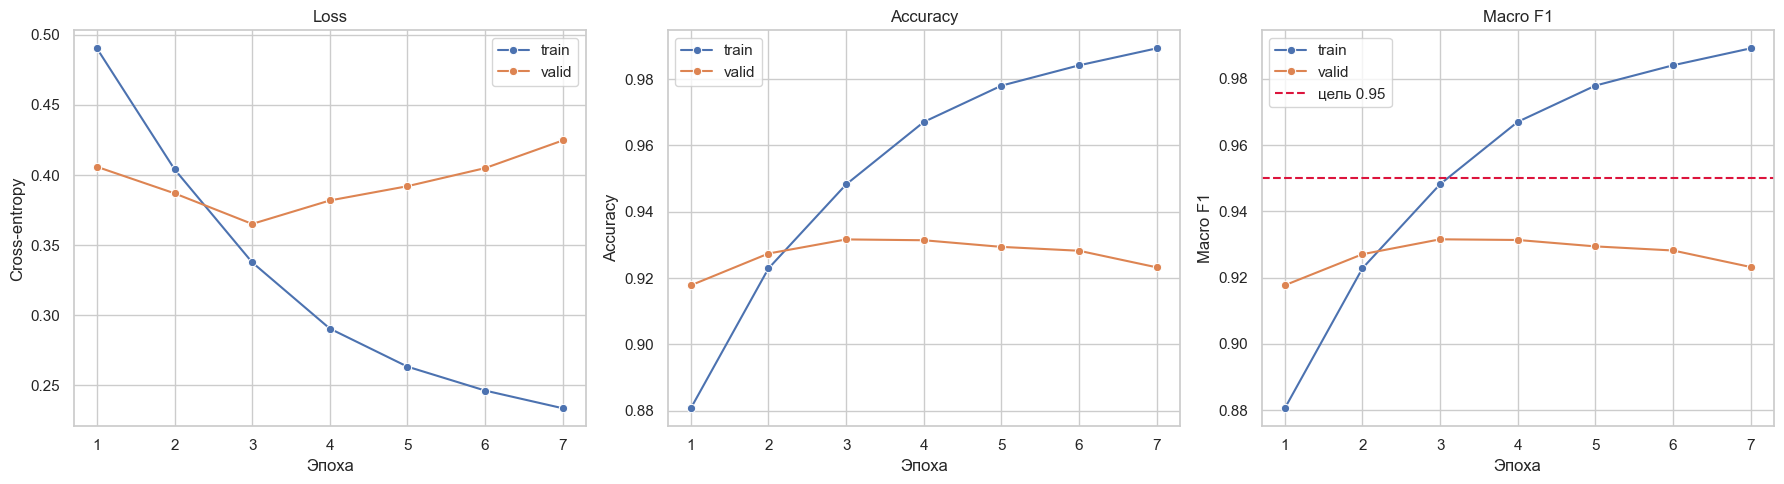

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=history, x="epoch", y="train_loss", marker="o", label="train", ax=axes[0])
sns.lineplot(data=history, x="epoch", y="valid_loss", marker="o", label="valid", ax=axes[0])
axes[0].set_title("Loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Cross-entropy")

sns.lineplot(data=history, x="epoch", y="train_accuracy", marker="o", label="train", ax=axes[1])
sns.lineplot(data=history, x="epoch", y="valid_accuracy", marker="o", label="valid", ax=axes[1])
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")

sns.lineplot(data=history, x="epoch", y="train_macro_f1", marker="o", label="train", ax=axes[2])
sns.lineplot(data=history, x="epoch", y="valid_macro_f1", marker="o", label="valid", ax=axes[2])
axes[2].axhline(TARGET_MACRO_F1, color="crimson", linestyle="--", label="цель 0.95")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Эпоха")
axes[2].set_ylabel("Macro F1")
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Финальная оценка на test

In [13]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

test_metrics = evaluate(model, test_loader, caption="Test")
print(f"Test loss:     {test_metrics['loss']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test macro F1: {test_metrics['macro_f1']:.4f}")
print()
print(classification_report(
    test_metrics["labels"],
    test_metrics["predictions"],
    target_names=LABEL_NAMES,
    digits=4,
))


Test:   0%|          | 0/30 [00:00<?, ?it/s]

Test loss:     0.3726
Test accuracy: 0.9293
Test macro F1: 0.9293

              precision    recall  f1-score   support

       World     0.9431    0.9247    0.9338      1900
      Sports     0.9745    0.9853    0.9798      1900
    Business     0.9145    0.8784    0.8961      1900
    Sci/Tech     0.8865    0.9289    0.9072      1900

    accuracy                         0.9293      7600
   macro avg     0.9297    0.9293    0.9293      7600
weighted avg     0.9297    0.9293    0.9293      7600



## 13. Confusion matrix на test

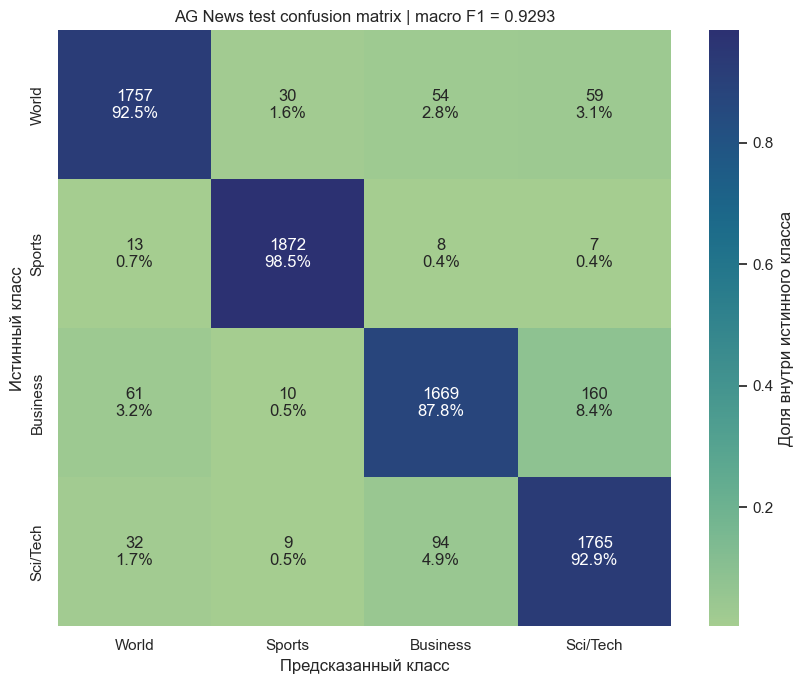

In [14]:
test_matrix = confusion_matrix(test_metrics["labels"], test_metrics["predictions"])
test_matrix_norm = test_matrix / test_matrix.sum(axis=1, keepdims=True)

annotations = np.empty_like(test_matrix).astype(str)
for row in range(test_matrix.shape[0]):
    for col in range(test_matrix.shape[1]):
        annotations[row, col] = f"{test_matrix[row, col]}\n{test_matrix_norm[row, col]:.1%}"

plt.figure(figsize=(8.5, 7))
sns.heatmap(
    test_matrix_norm,
    annot=annotations,
    fmt="",
    cmap="crest",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cbar_kws={"label": "Доля внутри истинного класса"},
)
plt.title(f"AG News test confusion matrix | macro F1 = {test_metrics['macro_f1']:.4f}")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()